# 03 — Model Training & Evaluation

**Group D — Grid Load Prediction**

Full training with cross-validation across several candidate models, using the **cleaned data** (from `00_data_understanding`) and the **engineered features** (from `02_feature_eng`). All code is written directly in this notebook — nothing is imported from `src/` — so the whole pipeline is readable end-to-end.

**Assignment tasks covered here:**
- **Task 10** — Data splitting & model training
- **Task 11** — Cross-validation & model evaluation
- **Overfitting evaluation** — train/test gap + learning curve
- (feeds **Task 12** — picking the best model for the conclusions)

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set_theme(style='whitegrid')

# locate repo root so paths work whether run from notebooks/ or repo root
REPO = Path.cwd()
while not (REPO / 'data').exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / 'reports' / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)
PROC = REPO / 'data' / 'processed'
print('repo:', REPO)

repo: /home/winzer/code/python/class/aion-gridload


## 1. Load the cleaned dataset
Produced by the cleaning step in `00_data_understanding` (dirty tokens + out-of-range values handled, duplicates dropped, median-imputed).

In [2]:
df = pd.read_csv(PROC / 'grid_load_clean.csv')
print('rows, cols:', df.shape, '| missing cells:', int(df.isna().sum().sum()))
df.head()

rows, cols: (1480, 11) | missing cells: 0


,Record_ID,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,1,Central,20.0,0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,2,Eastern,13.0,0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,3,Western,14.0,4,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,4,Northern,10.0,0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,5,Northern,12.0,0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


## 2. Feature engineering (same recipe as `02_feature_eng`, inline)
Drop the non-predictive ID, build peak-hour and weekend flags, and label-encode Region.

In [3]:
data = df.copy()
data = data.drop(columns=['Record_ID'])              # ID carries no signal

# peak-hour flags: demand is highest in these windows
data['Morning_Peak'] = data['Hour'].isin([6,7,8,9]).astype(int)
data['Evening_Peak'] = data['Hour'].isin([17,18,19,20]).astype(int)

# calendar flags
data['Is_Weekend']     = data['DayOfWeek'].isin([5,6]).astype(int)
data['Is_Working_Day'] = (data['DayOfWeek'] < 5).astype(int)

# encode Region (text -> integer code)
region_codes = {r: i for i, r in enumerate(sorted(data['Region'].unique()))}
data['Region_Encoded'] = data['Region'].map(region_codes)
print('Region encoding:', region_codes)
data.head()

Region encoding: {'Central': 0, 'Eastern': 1, 'Northern': 2, 'Western': 3}


,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW,Morning_Peak,Evening_Peak,Is_Weekend,Is_Working_Day,Region_Encoded
0,Central,20.0,0,26.7,52.0,3.1,93.0,89.0,0.03,850.3,0,1,0,1,0
1,Eastern,13.0,0,18.5,63.0,3.7,95.0,89.0,0.38,788.3,0,0,0,1,1
2,Western,14.0,4,22.7,90.0,3.3,71.0,55.0,0.13,548.0,0,0,0,1,3
3,Northern,10.0,0,19.6,41.0,0.1,75.0,78.0,0.45,604.6,0,0,0,1,2
4,Northern,12.0,0,27.4,88.0,0.0,86.0,58.0,0.70,546.1,0,0,0,1,2


## 3. Assemble the model matrix
Target = `GridLoad_MW`. Drop the raw text `Region` (keep its encoded version). Save the feature-engineered table so it is reusable.

In [4]:
TARGET = 'GridLoad_MW'
feature_cols = ['Hour','DayOfWeek','Temperature_C','Humidity_pct','Rainfall_mm',
                'PopulationIndex','IndustrialIndex','SolarGenerationIndex',
                'Morning_Peak','Evening_Peak','Is_Weekend','Is_Working_Day','Region_Encoded']
X = data[feature_cols].copy()
y = data[TARGET].copy()

# persist the engineered dataset for reuse
data[feature_cols + [TARGET]].to_csv(PROC / 'grid_load_features.csv', index=False)
print('feature matrix:', X.shape, '-> saved data/processed/grid_load_features.csv')
X.describe().T[['min','max','mean','std']].round(2)

feature matrix: (1480, 13) -> saved data/processed/grid_load_features.csv


,min,max,mean,std
Hour,0.0,23.0,11.93,7.06
DayOfWeek,0.0,6.0,3.04,2.00
Temperature_C,18.0,35.0,26.53,4.98
Humidity_pct,35.0,95.0,64.07,17.54
Rainfall_mm,0.0,18.4,4.09,3.96
PopulationIndex,50.0,100.0,75.15,14.55
IndustrialIndex,20.0,95.0,57.87,21.75
SolarGenerationIndex,0.0,1.8,0.25,0.22
Morning_Peak,0.0,1.0,0.16,0.36
Evening_Peak,0.0,1.0,0.18,0.38


## 4. Inspect the training signal
Quick look at how features relate to the target before modelling.

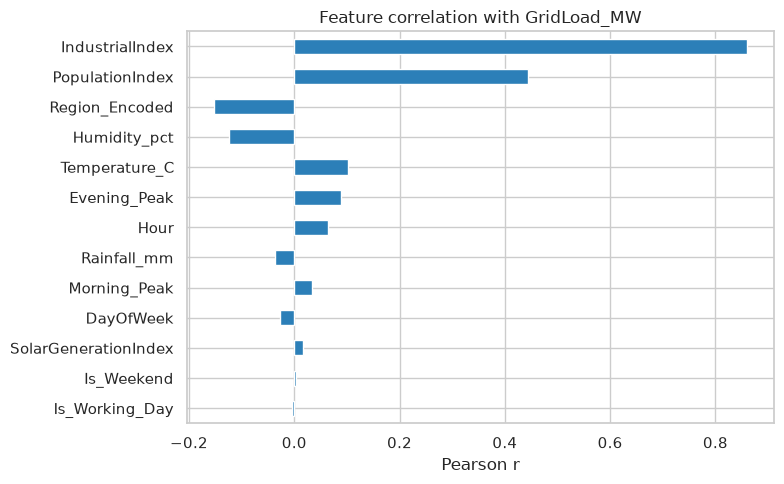

IndustrialIndex         0.861
PopulationIndex         0.443
Region_Encoded         -0.153
Humidity_pct           -0.125
Temperature_C           0.102
Evening_Peak            0.088
Hour                    0.065
Rainfall_mm            -0.037
Morning_Peak            0.034
DayOfWeek              -0.028
SolarGenerationIndex    0.016
Is_Weekend              0.004
Is_Working_Day         -0.004
Name: GridLoad_MW, dtype: float64

In [5]:
corr_target = X.join(y).corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
corr_target.plot.barh(ax=ax, color='#2c7fb8'); ax.invert_yaxis()
ax.set_title('Feature correlation with GridLoad_MW'); ax.set_xlabel('Pearson r')
fig.tight_layout(); fig.savefig(FIGS/'03_feature_target_corr.png', dpi=120); plt.show()
corr_target.round(3)

## 5. ✅ Task 10 — Train/test split
80/20 split. Data is cross-sectional (no time ordering), so a shuffled split is appropriate.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)

train: (1184, 13) | test: (296, 13)


## 6. Candidate models
Same shortlist used in the earlier modelling experiments — a mean baseline (any real model must beat it), two linear models, and three tree-based models.

In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Baseline (mean)': DummyRegressor(strategy='mean'),
    # linear models get a scaler (tree models are scale-invariant, so they run raw)
    'LinearRegression': Pipeline([('scale', StandardScaler()), ('m', LinearRegression())]),
    'Ridge': Pipeline([('scale', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}
list(models)

['Baseline (mean)',
 'LinearRegression',
 'Ridge',
 'DecisionTree',
 'RandomForest',
 'GradientBoosting']

## 7. ✅ Task 11 — Cross-validation
5-fold shuffled K-Fold. We report CV RMSE (mean ± std) and CV R² for every candidate — cross-validation gives a more reliable estimate than a single split.

In [8]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = {}
for name, model in models.items():
    rmse = -cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    r2   =  cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    cv_rows[name] = {'cv_rmse_mean': rmse.mean(), 'cv_rmse_std': rmse.std(), 'cv_r2_mean': r2.mean()}
cv_table = pd.DataFrame(cv_rows).T.sort_values('cv_rmse_mean').round(3)
cv_table

,cv_rmse_mean,cv_rmse_std,cv_r2_mean
GradientBoosting,15.996,3.241,0.975
LinearRegression,18.524,3.144,0.966
Ridge,18.524,3.143,0.966
RandomForest,23.098,2.799,0.948
DecisionTree,35.090,1.898,0.882
Baseline (mean),102.516,2.638,-0.001


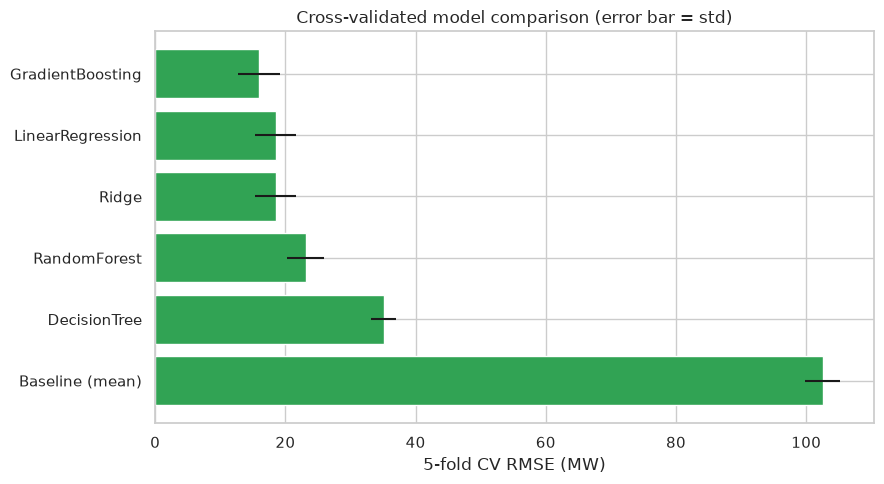

In [9]:
# visualise CV RMSE with error bars
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(cv_table.index, cv_table['cv_rmse_mean'], xerr=cv_table['cv_rmse_std'], color='#31a354')
ax.invert_yaxis(); ax.set_xlabel('5-fold CV RMSE (MW)')
ax.set_title('Cross-validated model comparison (error bar = std)')
fig.tight_layout(); fig.savefig(FIGS/'03_cv_model_comparison.png', dpi=120); plt.show()

## 8. ✅ Task 11 — Held-out test evaluation
Fit each model on the training set and score on the untouched test set with several metrics.

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    return {'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAE': mean_absolute_error(yt, yp),
            'R2': r2_score(yt, yp),
            'MAPE%': np.mean(np.abs((yt-yp)/yt))*100}

test_rows, fitted = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    test_rows[name] = metrics(y_test, model.predict(X_test))
test_table = pd.DataFrame(test_rows).T.sort_values('RMSE').round(3)
test_table

,RMSE,MAE,R2,MAPE%
GradientBoosting,13.961,11.478,0.982,1.881
Ridge,18.084,14.602,0.969,2.405
LinearRegression,18.096,14.610,0.969,2.407
RandomForest,21.582,17.544,0.956,2.871
DecisionTree,31.554,25.134,0.906,4.118
Baseline (mean),102.808,85.248,-0.003,14.413


## 8b. ✅ Overfitting check — train vs test gap
Compare each model's error on data it trained on vs the held-out test set. A large **gap (test − train)** means the model memorised the training data instead of generalising.

In [11]:
of_rows = {}
for name, model in fitted.items():
    tr = metrics(y_train, model.predict(X_train))['RMSE']
    te = metrics(y_test,  model.predict(X_test))['RMSE']
    of_rows[name] = {'train_RMSE': tr, 'test_RMSE': te, 'gap': te - tr,
                     'gap_ratio': (te - tr) / tr if tr else np.nan}
overfit = pd.DataFrame(of_rows).T.sort_values('gap', ascending=False).round(3)
overfit

,train_RMSE,test_RMSE,gap,gap_ratio
DecisionTree,15.043,31.554,16.511,1.098
RandomForest,8.859,21.582,12.723,1.436
GradientBoosting,10.453,13.961,3.508,0.336
Baseline (mean),102.471,102.808,0.337,0.003
LinearRegression,18.793,18.096,-0.697,-0.037
Ridge,18.794,18.084,-0.710,-0.038


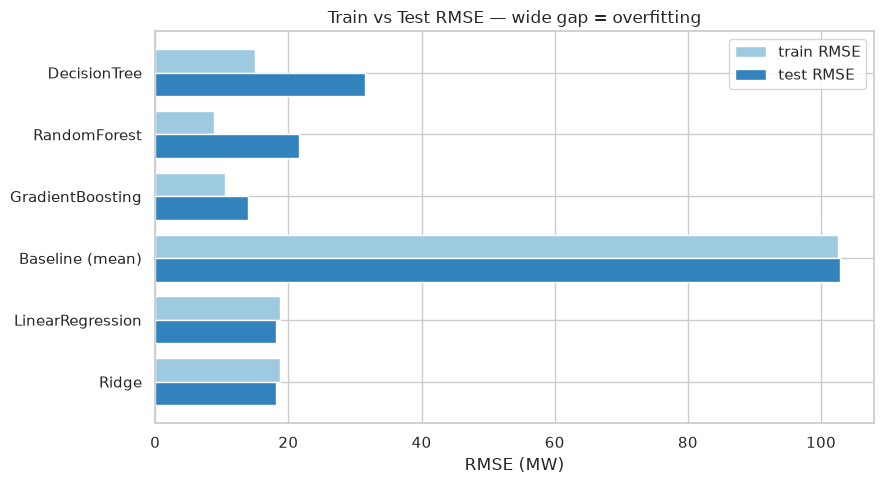

In [12]:
fig, ax = plt.subplots(figsize=(9,5))
idx = np.arange(len(overfit)); w = 0.38
ax.barh(idx - w/2, overfit['train_RMSE'], w, label='train RMSE', color='#9ecae1')
ax.barh(idx + w/2, overfit['test_RMSE'],  w, label='test RMSE',  color='#3182bd')
ax.set_yticks(idx); ax.set_yticklabels(overfit.index); ax.invert_yaxis()
ax.set_xlabel('RMSE (MW)'); ax.set_title('Train vs Test RMSE — wide gap = overfitting'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'03_overfitting_gap.png', dpi=120); plt.show()

**Interpretation:** models near the top of the table (largest gap) overfit most — typically DecisionTree/RandomForest, which fit the training data almost perfectly but generalise worse. A small, stable gap (e.g. linear models, tuned boosting) is the healthy sign we want in the chosen model.

## 9. Best model — diagnostics
Pick the lowest-CV-RMSE model and look at actual-vs-predicted, residuals and importances.

In [13]:
best_name = cv_table.index[0]
best_model = fitted[best_name]
pred = best_model.predict(X_test)
print('Best model by CV RMSE:', best_name)
print('Test metrics:', {k: round(v,3) for k,v in metrics(y_test, pred).items()})

Best model by CV RMSE: GradientBoosting
Test metrics: {'RMSE': np.float64(13.961), 'MAE': 11.478, 'R2': 0.982, 'MAPE%': np.float64(1.881)}


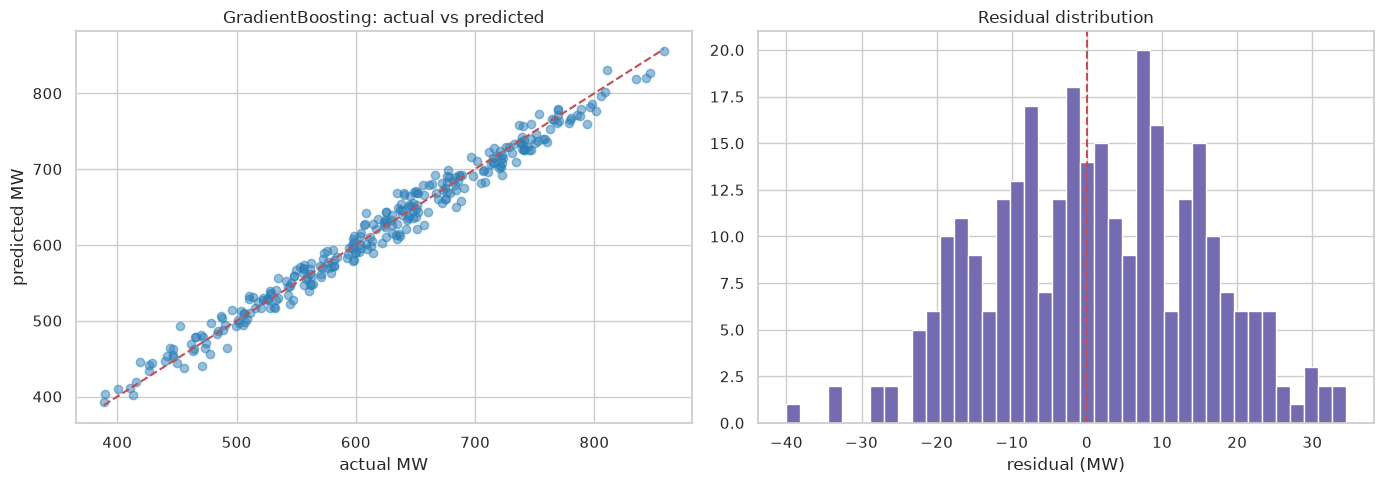

In [14]:
resid = y_test.values - pred
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].scatter(y_test, pred, alpha=.5, color='#2c7fb8')
lims=[min(y_test.min(),pred.min()), max(y_test.max(),pred.max())]
ax[0].plot(lims, lims, 'r--'); ax[0].set_xlabel('actual MW'); ax[0].set_ylabel('predicted MW')
ax[0].set_title(f'{best_name}: actual vs predicted')
ax[1].hist(resid, bins=40, color='#756bb1', edgecolor='white'); ax[1].axvline(0, color='r', ls='--')
ax[1].set_title('Residual distribution'); ax[1].set_xlabel('residual (MW)')
fig.tight_layout(); fig.savefig(FIGS/'03_best_actual_vs_pred.png', dpi=120); plt.show()

In [15]:
# feature importance (tree models expose it; else use |coef| from the linear pipeline)
est = best_model[-1] if hasattr(best_model, '__getitem__') else best_model
if hasattr(est, 'feature_importances_'):
    imp = pd.Series(est.feature_importances_, index=feature_cols)
elif hasattr(est, 'coef_'):
    imp = pd.Series(np.abs(est.coef_), index=feature_cols)
else:
    imp = None
if imp is not None:
    imp = imp.sort_values().tail(13)
    fig, ax = plt.subplots(figsize=(9,6))
    imp.plot.barh(ax=ax, color='#e6550d'); ax.set_title(f'{best_name} — feature importance')
    fig.tight_layout(); fig.savefig(FIGS/'03_best_feature_importance.png', dpi=120); plt.show()
    display(imp.sort_values(ascending=False).to_frame('importance').round(4))

## 9b. ✅ Learning curve — is the best model overfitting?
Train and CV error vs training-set size. Converging curves = healthy; a large persistent gap = high variance (overfitting); both high & flat = underfitting.

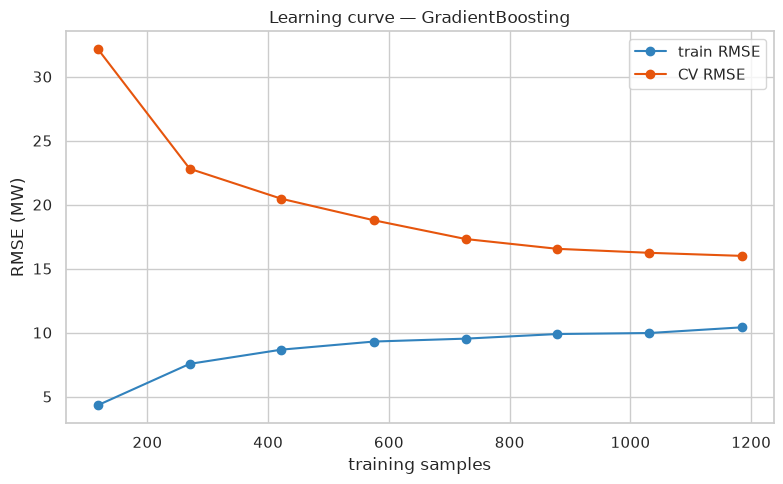

In [16]:
from sklearn.model_selection import learning_curve
sizes, tr_sc, va_sc = learning_curve(
    models[best_name], X, y, train_sizes=np.linspace(0.1, 1.0, 8), cv=cv,
    scoring='neg_root_mean_squared_error', n_jobs=-1)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sizes, -tr_sc.mean(1), 'o-', label='train RMSE', color='#3182bd')
ax.plot(sizes, -va_sc.mean(1), 'o-', label='CV RMSE', color='#e6550d')
ax.set_xlabel('training samples'); ax.set_ylabel('RMSE (MW)')
ax.set_title(f'Learning curve — {best_name}'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'03_learning_curve.png', dpi=120); plt.show()

## 10. Save the best model & metrics
Refit on all data and persist to `best_model/` for reuse and the report.

In [17]:
final = fitted[best_name]
final.fit(X, y)                     # refit on the full dataset
bm = REPO / 'best_model'; bm.mkdir(exist_ok=True)
joblib.dump(final, bm / 'best_model.joblib')
pd.Series({'model': best_name, **metrics(y_test, pred)}).to_csv(bm / 'metrics.csv')
pd.Series(feature_cols, name='feature').to_csv(bm / 'feature_names.csv', index=False)
cv_table.to_csv(bm / 'cv_results.csv')
print('Saved best_model/: best_model.joblib, metrics.csv, feature_names.csv, cv_results.csv')

Saved best_model/: best_model.joblib, metrics.csv, feature_names.csv, cv_results.csv


## Summary — tasks completed in this notebook
- **Task 10** — split the cleaned+engineered data 80/20 and trained 6 candidate models.
- **Task 11** — 5-fold cross-validation (RMSE + R²) plus held-out test metrics for all.
- **Overfitting evaluation** — train-vs-test gap table/chart and a learning curve for the best model.
- **Best model** selected by CV RMSE, diagnosed (actual-vs-predicted, residuals, importance) and saved to `best_model/`.
- Engineered dataset saved to `data/processed/grid_load_features.csv`; figures to `reports/figures/03_*.png`.
- Next: `Task 12` — write conclusions/recommendations from these results.